In [9]:
import pandas as pd
from pathlib import Path
from ifc.config import load_data_config
from ifc.config import resolve_project_root

data_cfg = load_data_config()

train_path, test_path = data_cfg.resolve_paths()

print(train_path)

train_df = pd.read_csv(train_path)

C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\train_data.csv


## **7. Geographic Coverage**

Before examining aspects related to geographical location, we need to analyze the distribution of companies across different areas of Italy.
Our goal is to assess how accurately the data represents reality and what biases it may contain.
This will allow us to understand the results of our models, rather than finding direct links between geographical location and revenue growth.

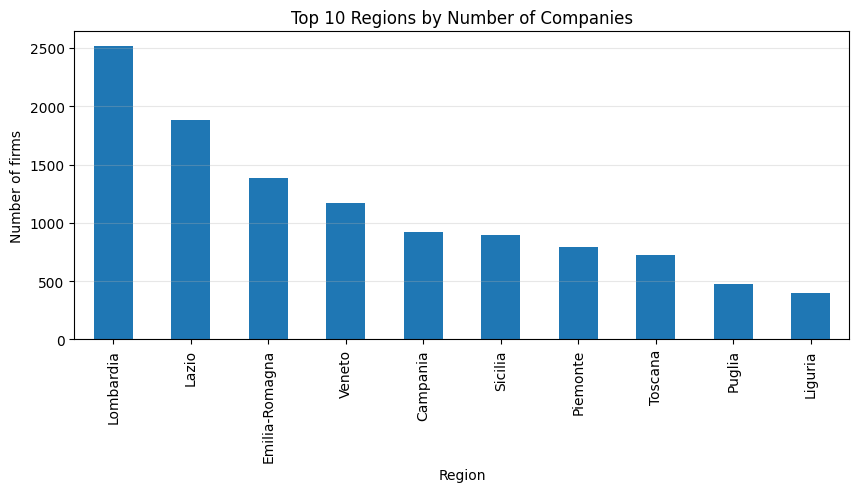

In [10]:
# Company count by region
region_counts = train_df['region'].value_counts().sort_values(ascending=False)
region_counts.head(10)

import matplotlib.pyplot as plt
region_counts.head(10).plot(kind='bar', figsize=(10,4))
plt.title("Top 10 Regions by Number of Companies")
plt.ylabel("Number of firms")
plt.xlabel("Region")
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
# Missing province by region
province_missing = (
    train_df.assign(province_missing=train_df["province"].isna())
            .groupby("region")["province_missing"]
            .mean()
            .sort_values(ascending=False)
)

province_missing.head(10)

region
Campania                 1.0
Emilia-Romagna           0.0
Friuli-Venezia Giulia    0.0
Lazio                    0.0
Liguria                  0.0
Lombardia                0.0
Piemonte                 0.0
Puglia                   0.0
Sardegna                 0.0
Sicilia                  0.0
Name: province_missing, dtype: float64

We do this as we want to understand if there is a pattern with the missing provinces values, if either they are random or concentrated in a specific region.

### **Interpretation**
The graph above shows that the distribution of companies across regions is uneven, with a high concentration in regions such as ***Lombardia and Lazio***.

This means that the data is not evenly distributed across different areas, so reagions with a higher number of companies or representatives may have a greater influence on the results.

The dataset includes more data from economically important regions, especially **Lombardia**. Regions like **Lazio**, **Emilia-Romagna**, and **Veneto** also have a lot of representation. In comparison, southern regions such as **Campania**, **Sicilia**, and **Puglia** have fewer observations, but they are still included.

This highlights how the missing data *isn’t random*, but it reflects the uneven geographic coverage.



## **8. Company Size Buckets**
One of the factors that most influences financial stability is the size of the company. To measure this aspect, we use total assets and group companies according to their size to see whether their revenue varies significantly depending on size.

In [12]:
#Use train-years only to define buckets
#We want to convert continuous variable into size categories(bucketing)
size_df = train_df.copy() #so we don't modify the train_df

size_df['size_bucket'] = pd.qcut(
    size_df['total_assets'],
    q=4,                                                      #splititng companies into 4 groups with the same number of obs.
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

size_summary = (
    size_df
    .groupby('size_bucket')['revenue_change']     #for each size bucket we will have all revenue changes
    .agg(                                         #summary stats for each size bucket
        count='count',                            #count will enable us to see how many obs in each bucket
        p25=lambda x: x.quantile(0.25),
        median='median',
        p75=lambda x: x.quantile(0.75),
        p95=lambda x: x.quantile(0.95),
        IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
)

size_summary

C:\Users\morio\AppData\Local\Temp\ipykernel_9540\1922321081.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('size_bucket')['revenue_change']     #for each size bucket we will have all revenue changes


,count,p25,median,p75,p95,IQR
size_bucket,,,,,,
Small,2189,-89.96,-72.180,-23.4200,176.3220,66.5400
Medium,2185,-70.12,-22.970,91.0100,519.9560,161.1300
Large,2235,-37.63,67.980,317.4350,1360.0600,355.0650
Very Large,2220,16.17,265.865,998.3575,4875.9955,982.1875


We divide firm size into four groups based on total assets. This changes a complex number into clear categories (Small, Medium, Large, Very Large), making it easier to compare revenue changes across different firm sizes without being affected by very high or very low asset values.

### **Interpretation**
The table highlights how the central distribution of revenues changes based on company size.

For small and medium-sized enterprises, both the median and interquartile range (IQR) are below or close to zero, highlighting that most companies in these categories experience weak or negative revenue growth.



As companies grow, their revenue variations tend to be higher and more widespread.   Large companies have a positive median, but they can still experience significant losses. Very large companies show positive revenue variations even at the 25th percentile. The increase in IQR for all sizes means that as companies grow, their financial results become more variable, especially at the upper end of the distribution.

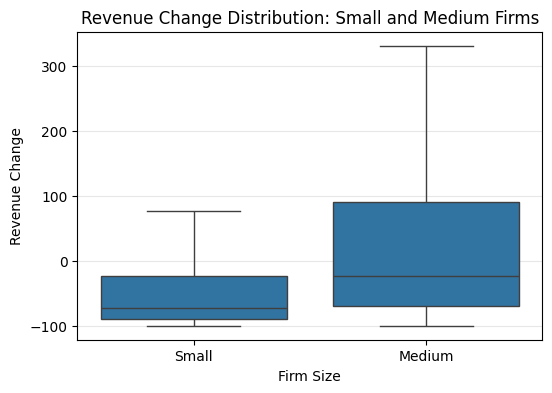

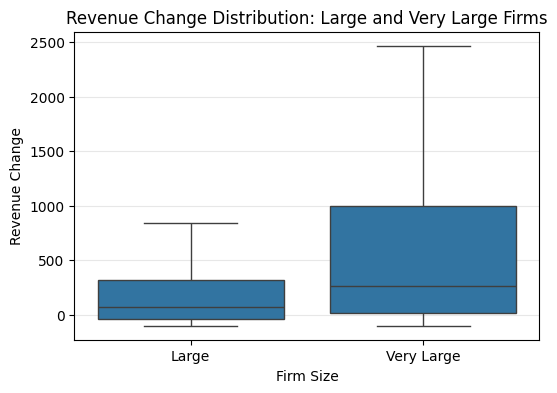

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot: Small & Medium firms
plt.figure(figsize=(6,4))

sns.boxplot(
    data=size_df[size_df['size_bucket'].isin(['Small', 'Medium'])],
    x='size_bucket',
    y='revenue_change',
    order=['Small', 'Medium'],   
    showfliers=False
)

plt.title("Revenue Change Distribution: Small and Medium Firms")
plt.ylabel("Revenue Change")
plt.xlabel("Firm Size")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Boxplot: Large & Very Large firms
plt.figure(figsize=(6,4))

sns.boxplot(
    data=size_df[size_df['size_bucket'].isin(['Large', 'Very Large'])],
    x='size_bucket',
    y='revenue_change',
    order=['Large', 'Very Large'],   
    showfliers=False
)

plt.title("Revenue Change Distribution: Large and Very Large Firms")
plt.ylabel("Revenue Change")
plt.xlabel("Firm Size")
plt.grid(axis='y', alpha=0.3)
plt.show()

### **Interpretation: Small and Medium Firms**

The first box plot concerns **small and medium-sized enterprises**, where most of the changes in turnover are negative.

For small-sized firms, the results are very similar, with both the median and IQR **below zero (negative)**.

This means that most small businesses are experiencing similar and fairly common declines in turnover.

Medium-sized enterprises still have a **negative median**, but their results are more widely distributed. Some of these companies continue to experience a decline in revenue, but there are also others that are experiencing some growth. This shows that medium-sized enterprises have more variable and uncertain results than small enterprises.


###**Interpretation: Large and Very-large Firms**

For **large** firms, the median variation in revenues becomes positive and the results are distributed in both directions. This means that growth is more common, but there is also greater variation than among **smaller** or **medium-sized** firms.

For **very large** firms, the range of outcomes becomes much wider, with some companies experiencing extremely high revenue increases. This shows that very large firms are more likely to experience unusual but significant increases in revenue, often due to major events such as mergers or acquisitions.

However, negative outcomes are still possible, so being larger does not eliminate risk, but only leads to more unpredictable outcomes.

In conclusion, this model shows that a company’s size mainly affects how likely it is to see big changes in revenue, not its everyday performance.